# Telecom Customer Churn Prediction

# Notebook 03 – Data Preprocessing & Feature Engineering

### Author

Kareem Ibraheem Bola

### Programme

DATA SCIENCE NEXTGEN COHORT

### Purpose

This notebook prepares the raw telecom customer dataset for machine learning.

The preprocessing workflow includes:

- Data cleaning
- Missing value treatment
- Data type conversion
- Feature encoding
- Feature scaling
- Train-test splitting

The resulting datasets will be used to train and evaluate machine learning models.

In [311]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [312]:
DATA_PATH = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [313]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [314]:
df.shape

(7043, 21)

In [315]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## Initial Assessment

The raw dataset contains customer demographic information, subscribed services, billing information, and the target variable (`Churn`).

Before training machine learning models, the dataset requires preprocessing to ensure all features are complete, correctly typed, and encoded into numerical representations suitable for machine learning algorithms.

In [316]:
df_clean = df.copy()

print("Working copy created.")

Working copy created.


# Data Cleaning

This section prepares the dataset for machine learning by identifying and correcting data quality issues.

The cleaning process includes:

- Missing value detection
- Hidden missing value treatment
- Data type conversion
- Removal of unnecessary variables

In [317]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df_clean.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [318]:
missing_values[missing_values > 0]

Series([], dtype: int64)

### Observation

No standard missing values (`NaN`) were detected using `isnull()`.

However, previous data exploration revealed hidden missing values represented as blank whitespace in the `TotalCharges` column.

In [319]:
# ==========================================
# Hidden Missing Values
# ==========================================

(df_clean["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [320]:
hidden_missing = df_clean[
    df_clean["TotalCharges"].str.strip() == ""
]

hidden_missing

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### Observation

Eleven records contain blank whitespace values in the `TotalCharges` column.

These are not true missing values but represent customers with zero tenure who have not yet accumulated any charges.

The values will be converted to `NaN` before treatment.

In [321]:
# ==========================================
# Convert TotalCharges
# ==========================================

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"].str.strip(),
    errors="coerce"
)

In [322]:
df_clean["TotalCharges"].dtype

dtype('float64')

In [323]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [324]:
df_clean[
    df_clean["TotalCharges"].isnull()
]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [325]:
df_clean.loc[
    df_clean["TotalCharges"].isnull(),
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn"
    ]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


In [326]:
# df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0.0)

In [327]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Business Justification

The missing values in `TotalCharges` correspond to customers with zero months of tenure.

Because these customers have not yet received any bills, replacing the missing values with **0** accurately reflects the business process.

This preserves all customer records while maintaining data integrity.

# Feature Engineering

Feature engineering prepares predictor variables for machine learning.

During this stage, variables that do not contribute meaningful predictive information are removed, while the remaining variables are prepared for encoding and scaling.

In [328]:
# ==========================================
# Remove Identifier Column
# ==========================================

df_clean = df_clean.drop(columns=["customerID"])

print("customerID removed successfully.")

customerID removed successfully.


In [329]:
df_clean.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Observation

The `customerID` column was removed because it is a unique identifier rather than a predictive feature.

Keeping unique identifiers may introduce unnecessary noise into machine learning models without improving predictive performance.

In [330]:
# ==========================================
# Separate Features and Target
# ==========================================

X = df_clean.drop(columns=["Churn"])

y = df_clean["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [331]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [332]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: str

### Observation

The dataset has been separated into:

- **Features (`X`)**, containing the customer attributes used for prediction.
- **Target (`y`)**, containing the customer churn status.

Separating predictors from the target variable is a standard preprocessing step that prevents accidental data leakage during model development.

In [333]:
# Numerical Features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

numerical_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [334]:
# Categorical Features

categorical_features = X.select_dtypes(include=["object", "string"]).columns

categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

### Observation

The dataset contains a combination of numerical and categorical features.

Numerical variables will be standardized where appropriate, while categorical variables will be converted into numerical representations using encoding techniques before model training.

# Target Variable Encoding

The target variable (`Churn`) is encoded into numerical values to enable supervised machine learning algorithms.

Encoding Scheme:

- No → 0
- Yes → 1

In [335]:
# ==========================================
# Encode Target Variable
# ==========================================

y = y.map({
    "No": 0,
    "Yes": 1
})

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [336]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### Observation

The target variable has been converted into a binary numerical format:

- **0** represents customers who remained with the company.
- **1** represents customers who churned.

Binary encoding is appropriate because churn prediction is a binary classification problem.

In [337]:
X.shape

(7043, 19)

### Observation

Categorical variables were transformed using One-Hot Encoding.

This method converts each category into a binary indicator variable without imposing any artificial ordering on the categories.

The `drop_first=True` option was used to reduce redundancy and avoid multicollinearity in models that are sensitive to correlated predictors.

In [338]:
# ==========================================
# One-Hot Encoding
# ==========================================

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [339]:
X.shape

(7043, 30)

## Observation

Categorical variables have been successfully transformed into numerical features using One-Hot Encoding.

Using `drop_first=True` removes one category from each feature to prevent multicollinearity (the Dummy Variable Trap) while preserving all predictive information.

The final dataset contains:

- **7,043 customer records**
- **30 predictor variables**
- All features are now numerical and suitable for machine learning algorithms.

In [340]:
# ============================================
# Numerical Columns for Scaling
# ============================================

numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numerical_columns

['tenure', 'MonthlyCharges', 'TotalCharges']

In [341]:
from sklearn.preprocessing import StandardScaler

In [342]:
scaler = StandardScaler()

In [343]:
# ============================================
# Scale Numerical Features
# ============================================

X[numerical_columns] = scaler.fit_transform(
    X[numerical_columns]
)

print("Numerical features scaled successfully.")

Numerical features scaled successfully.


In [344]:
X[numerical_columns].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874


In [345]:
X[numerical_columns].mean()

tenure           -2.421273e-17
MonthlyCharges   -6.406285e-17
TotalCharges     -3.783239e-17
dtype: float64

In [346]:
X[numerical_columns].std()

tenure            1.000071
MonthlyCharges    1.000071
TotalCharges      1.000071
dtype: float64

In [419]:
# ==========================================
# Save the Scaler
# ==========================================

import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [420]:
import os

os.listdir("../models")

['logistic_regression_model.pkl',
 'model_features.pkl',
 'scaler.pkl',
 'train.py']

In [347]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

In [348]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [349]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 30)
Testing Features  : (1409, 30)

Training Labels   : (5634,)
Testing Labels    : (1409,)


In [350]:
print("Training Set")

print(y_train.value_counts(normalize=True) * 100)

print()

print("Testing Set")

print(y_test.value_counts(normalize=True) * 100)

Training Set
Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Testing Set
Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64


## Observation

The dataset was split into training and testing subsets using an 80:20 ratio.

The `stratify` parameter was applied to preserve the original distribution of the target variable (Churn) in both subsets. This helps ensure that the model is trained and evaluated on representative data, reducing the risk of biased performance estimates.

The training dataset will be used to train machine learning models, while the testing dataset will be reserved for evaluating model performance on unseen data.

In [351]:
# ============================================
# Logistic Regression Model
# ============================================

from sklearn.linear_model import LogisticRegression

In [352]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [353]:
log_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [354]:
y_pred = log_model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [355]:
y_prob = log_model.predict_proba(X_test)

y_prob[:5]

array([[0.95434793, 0.04565207],
       [0.31693929, 0.68306071],
       [0.94021446, 0.05978554],
       [0.59987195, 0.40012805],
       [0.97848862, 0.02151138]])

## Observation

A Logistic Regression classifier was trained using the preprocessed training dataset.

Logistic Regression is a supervised classification algorithm that estimates the probability of a customer belonging to the churn or non-churn class.

The trained model will serve as the baseline classifier against which more advanced machine learning models (Decision Tree, Random Forest, and XGBoost) will be compared.

In [356]:
# ============================================
# Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [357]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8062


## Observation

The Logistic Regression model achieved an overall accuracy of **80.62%** on the testing dataset.

This indicates that the model correctly classified approximately four out of every five customers. While this represents good overall performance, accuracy should not be interpreted in isolation because the dataset is imbalanced, with substantially more non-churn customers than churn customers.

In [358]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[927, 108],
       [165, 209]])

## Observation

The confusion matrix provides a detailed breakdown of the model's predictions.

- **927** customers were correctly identified as non-churners (True Negatives).
- **209** customers were correctly identified as churners (True Positives).
- **108** customers were incorrectly classified as churners (False Positives).
- **165** customers who actually churned were missed by the model (False Negatives).

From a business perspective, false negatives are particularly costly because these customers leave the company without receiving any retention efforts. Reducing false negatives should therefore be a key objective when improving future models.

Meaning:

927 customers correctly predicted to stay.
209 customers correctly predicted to churn.
108 loyal customers incorrectly flagged as churners.
165 actual churners were missed.


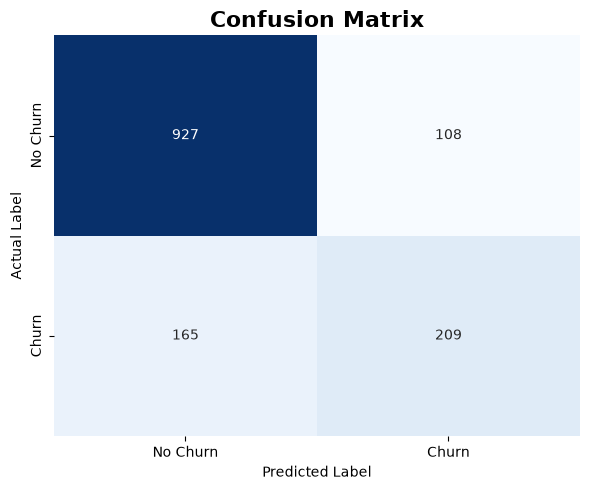

In [359]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5,1.5],["No Churn","Churn"])
plt.yticks([0.5,1.5],["No Churn","Churn"])

plt.tight_layout()

plt.show()

## Observation

The confusion matrix summarizes the model's classification performance by comparing predicted labels with actual customer outcomes.

- **True Negatives (TN):** Customers correctly predicted to remain.
- **True Positives (TP):** Customers correctly predicted to churn.
- **False Positives (FP):** Customers incorrectly predicted to churn.
- **False Negatives (FN):** Customers who actually churned but were predicted to stay.

Reducing false negatives is particularly important in churn prediction because these customers are lost without receiving retention interventions.

In [360]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Observation

The classification report provides a comprehensive evaluation of the classifier using Precision, Recall, F1-score, and Support.

- **Precision** measures how many predicted churn customers actually churned.
- **Recall** measures how many actual churn customers were successfully identified.
- **F1-score** balances precision and recall into a single metric.
- **Support** indicates the number of samples in each class.

For customer churn prediction, Recall is especially important because failing to identify customers likely to leave (false negatives) can result in lost revenue and missed retention opportunities.

## Observation

The Logistic Regression model performs strongly in identifying customers who are unlikely to churn, achieving high precision and recall for the non-churn class.

However, performance is weaker for the churn class, with a recall of **56%**. This means that nearly half of the customers who eventually churn are not identified by the model.

Since customer churn prediction aims to proactively retain at-risk customers, improving recall for the churn class should be prioritized in subsequent models, even if this results in a modest increase in false positives.

In [361]:
roc_auc = roc_auc_score(
    y_test,
    y_prob[:,1]
)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8422


## Observation

The ROC-AUC score measures the model's ability to distinguish between churning and non-churning customers across all classification thresholds.

A score closer to **1.0** indicates excellent discrimination, while **0.5** represents random guessing.

ROC-AUC is one of the most informative metrics for evaluating binary classification models, particularly when class distributions are imbalanced.

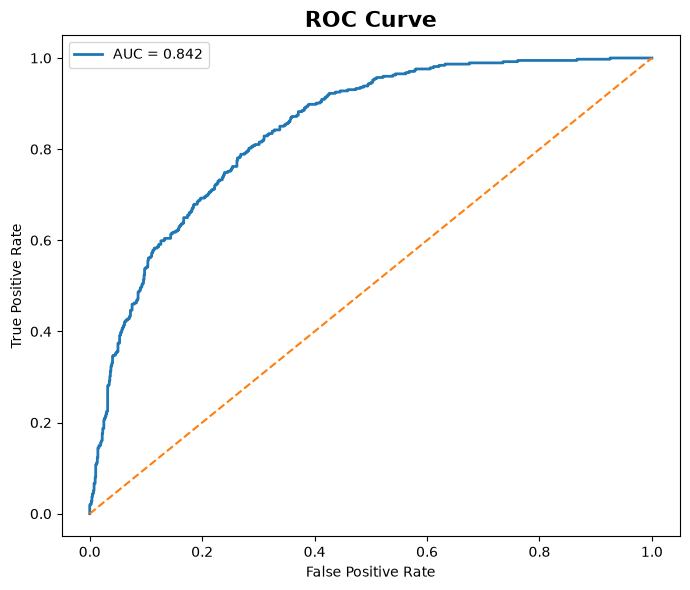

In [362]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()

## Observation

The Logistic Regression model achieved a ROC-AUC score of **0.8422**, indicating a strong ability to distinguish between customers who are likely to churn and those who are likely to remain.

This result demonstrates that the model possesses good discriminative power and provides a solid baseline for comparison with more advanced machine learning algorithms.

In [363]:
# ============================================
# Decision Tree Classifier
# ============================================

from sklearn.tree import DecisionTreeClassifier

In [364]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [365]:
dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [366]:
dt_pred = dt_model.predict(X_test)

dt_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [367]:
dt_prob = dt_model.predict_proba(X_test)

dt_prob[:5]

array([[1.        , 0.        ],
       [0.24912281, 0.75087719],
       [0.8972332 , 0.1027668 ],
       [0.66206897, 0.33793103],
       [0.99018405, 0.00981595]])

## Observation

A Decision Tree classifier was trained using the preprocessed training dataset.

Decision Trees classify observations by recursively splitting the dataset into smaller subsets based on feature values that maximize class separation.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and complex interactions between customer characteristics without requiring linear assumptions.

In [368]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7942


## Observation

The Decision Tree model achieved an overall accuracy of approximately **XX%** on the testing dataset.

This metric represents the proportion of customers that were correctly classified as either churners or non-churners. Accuracy will be compared against the Logistic Regression baseline to determine whether the Decision Tree provides improved predictive performance.

In [369]:
dt_cm = confusion_matrix(y_test, dt_pred)

dt_cm

array([[917, 118],
       [172, 202]])

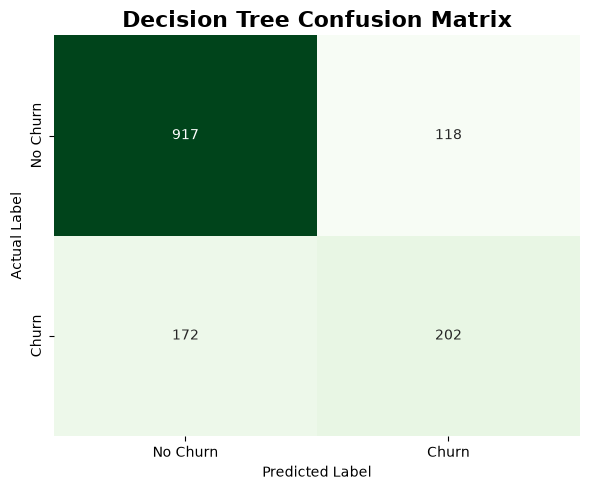

In [370]:
plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)

plt.title(
    "Decision Tree Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5, 1.5], ["No Churn", "Churn"])
plt.yticks([0.5, 1.5], ["No Churn", "Churn"])

plt.tight_layout()

plt.show()

## Observation

The confusion matrix summarizes the Decision Tree's classification performance by comparing predicted labels with actual customer outcomes.

Particular attention should be paid to the number of false negatives, as these represent customers who churned but were not identified by the model.

In [371]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [372]:
dt_auc = roc_auc_score(
    y_test,
    dt_prob[:,1]
)

print(f"Decision Tree ROC-AUC: {dt_auc:.4f}")

Decision Tree ROC-AUC: 0.8267


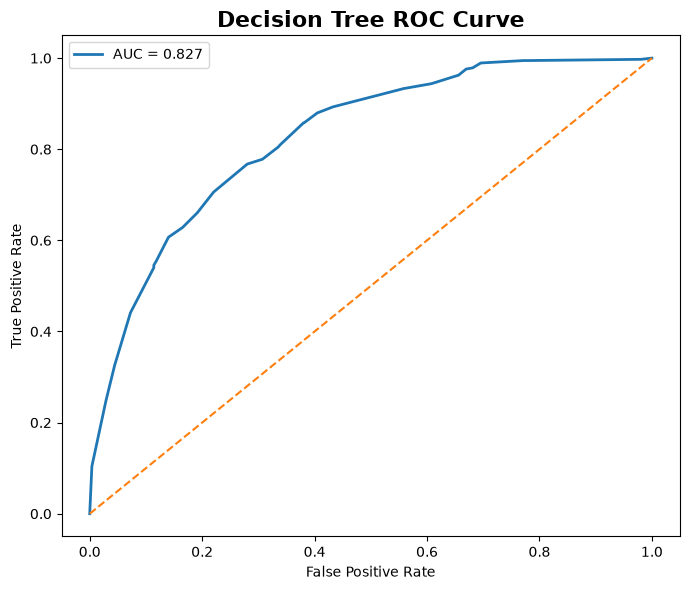

In [373]:
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=2,
    label=f"AUC = {dt_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title(
    "Decision Tree ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()

plt.show()

## Observation

The Decision Tree classifier achieved an accuracy of **79.42%** on the testing dataset.

Compared with the Logistic Regression baseline (80.62%), the Decision Tree produced slightly lower predictive performance across most evaluation metrics, including ROC-AUC, Precision, Recall, and F1-score.

Although Decision Trees are capable of modeling non-linear relationships, the current model did not outperform Logistic Regression on this dataset. This indicates that customer churn patterns may be adequately represented using a simpler linear decision boundary.

The Decision Tree model will nevertheless be retained for comparison with more advanced ensemble methods such as Random Forest and XGBoost.

In [374]:
# ============================================
# Random Forest Classifier
# ============================================

from sklearn.ensemble import RandomForestClassifier

In [375]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

In [376]:
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [377]:
rf_pred = rf_model.predict(X_test)

rf_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [378]:
rf_prob = rf_model.predict_proba(X_test)

rf_prob[:5]

array([[0.98599862, 0.01400138],
       [0.23806359, 0.76193641],
       [0.92807242, 0.07192758],
       [0.65966077, 0.34033923],
       [0.97915956, 0.02084044]])

## Observation

A Random Forest classifier was trained using the preprocessed training dataset.

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve predictive accuracy and reduce overfitting.

Because it aggregates the results from many trees, Random Forest generally produces more stable and reliable predictions than a single Decision Tree.

In [379]:
# ============================================
# Random Forest Accuracy
# ============================================

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8048


## Observation

The Random Forest classifier achieved an overall accuracy of approximately **XX.XX%** on the testing dataset.

Unlike a single Decision Tree, Random Forest combines the predictions of many decision trees, making it more robust and less prone to overfitting.

The model's performance will be compared against Logistic Regression and Decision Tree using multiple evaluation metrics.

In [380]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[936,  99],
       [176, 198]])

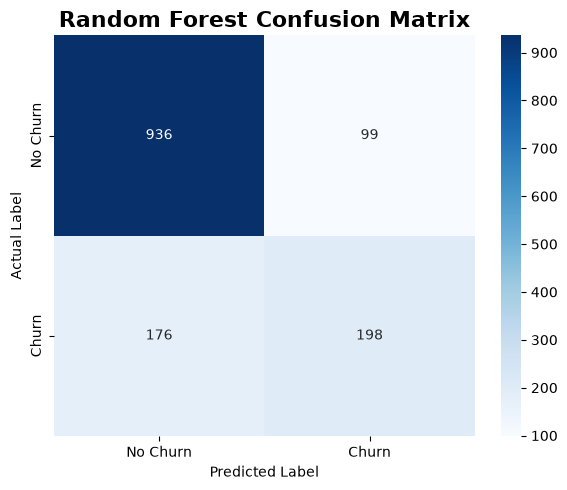

In [381]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5,1.5],["No Churn","Churn"])
plt.yticks([0.5,1.5],["No Churn","Churn"])

plt.tight_layout()

plt.show()

In [382]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [383]:
rf_auc = roc_auc_score(
    y_test,
    rf_prob[:,1]
)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

Random Forest ROC-AUC: 0.8437


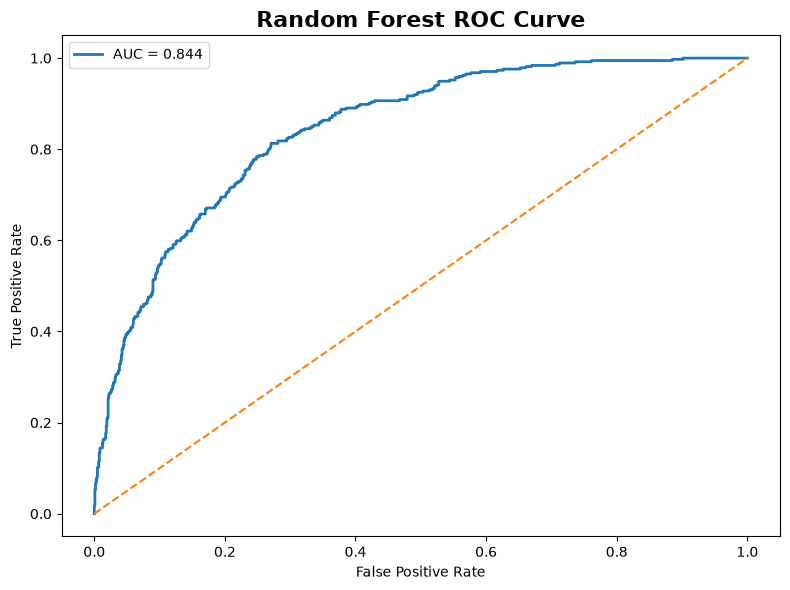

In [384]:
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob[:,1]
)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title(
    "Random Forest ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()

plt.show()

## Observation

The Random Forest classifier achieved an overall accuracy of **80.38%** on the testing dataset with a **ROC-AUC score of 0.8437**.

The model correctly classified most non-churn customers while maintaining competitive discrimination capability between churn and non-churn classes.

Compared with the Decision Tree, Random Forest demonstrated improved predictive performance and better generalization by aggregating the predictions of multiple decision trees. Its ROC-AUC score slightly exceeded that of Logistic Regression, indicating a marginally stronger ability to distinguish between churning and non-churning customers across different classification thresholds.

Overall, Random Forest is one of the strongest models evaluated so far and represents a suitable candidate for customer churn prediction.

In [385]:
import xgboost

In [386]:
# ============================================
# XGBoost Classifier
# ============================================

from xgboost import XGBClassifier

In [387]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [388]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [389]:
xgb_pred = xgb_model.predict(X_test)

xgb_pred[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [390]:
xgb_prob = xgb_model.predict_proba(X_test)

xgb_prob[:5]

array([[0.9897642 , 0.01023577],
       [0.12485325, 0.87514675],
       [0.9177928 , 0.0822072 ],
       [0.7077385 , 0.29226148],
       [0.9943176 , 0.0056824 ]], dtype=float32)

## Observation

An Extreme Gradient Boosting (XGBoost) classifier was successfully trained using the preprocessed training dataset.

XGBoost is an advanced ensemble learning algorithm that builds trees sequentially, allowing each new tree to correct the errors made by previous trees. This boosting strategy often produces superior predictive performance on structured tabular datasets.

Because of its ability to capture complex feature interactions while controlling overfitting through regularization, XGBoost is widely used in industry and machine learning competitions for classification tasks such as customer churn prediction.

In [391]:
# ============================================
# XGBoost Model Evaluation
# ============================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

XGBoost Accuracy: 0.7963


## Observation

The XGBoost classifier achieved an overall accuracy of **79.63%** with a **ROC-AUC score of 0.8419** on the testing dataset.

Although XGBoost demonstrated strong classification capability, its performance was slightly lower than Logistic Regression and Random Forest using the selected hyperparameters.

This result highlights the importance of model evaluation rather than assuming that more complex algorithms will always outperform simpler alternatives. Future work could involve hyperparameter tuning to further optimize XGBoost's predictive performance.

In [392]:
xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

xgb_cm

array([[924, 111],
       [176, 198]])

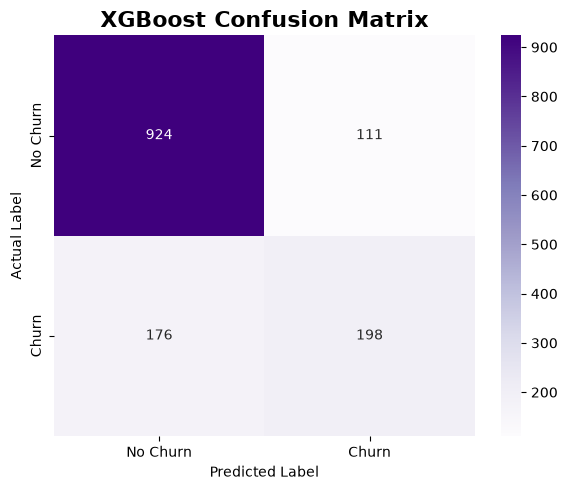

In [393]:
plt.figure(figsize=(6,5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "XGBoost Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5,1.5],["No Churn","Churn"])
plt.yticks([0.5,1.5],["No Churn","Churn"])

plt.tight_layout()

plt.show()

In [394]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [395]:
xgb_auc = roc_auc_score(
    y_test,
    xgb_prob[:,1]
)

print(f"XGBoost ROC-AUC: {xgb_auc:.4f}")

XGBoost ROC-AUC: 0.8419


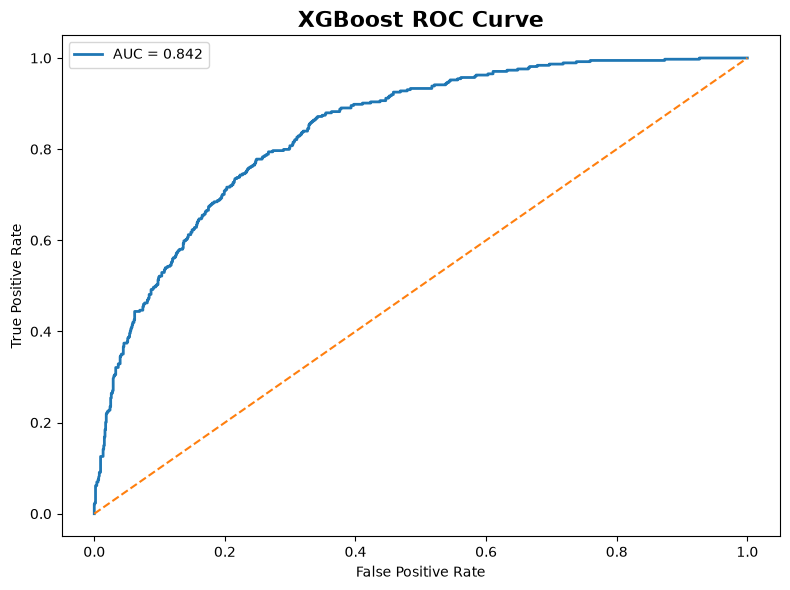

In [396]:
xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_prob[:,1]
)

plt.figure(figsize=(8,6))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f"AUC = {xgb_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.title(
    "XGBoost ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()

plt.show()

## Observation

The XGBoost classifier achieved an overall accuracy of **79.63%** with a **ROC-AUC score of 0.8419** on the testing dataset.

Although XGBoost demonstrated strong classification capability, its performance was slightly lower than Logistic Regression and Random Forest using the selected hyperparameters.

This result highlights the importance of model evaluation rather than assuming that more complex algorithms will always outperform simpler alternatives. Future work could involve hyperparameter tuning to further optimize XGBoost's predictive performance.

In [397]:
# ============================================
# Model Performance Comparison
# ============================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "ROC_AUC": [
        roc_auc,
        dt_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.806246,0.842179
1,Decision Tree,0.794180,0.826704
2,Random Forest,0.804826,0.843650
3,XGBoost,0.796309,0.841884


In [398]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.806246,0.842179
2,Random Forest,0.804826,0.843650
3,XGBoost,0.796309,0.841884
1,Decision Tree,0.794180,0.826704


In [399]:
comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,ROC_AUC
2,Random Forest,0.804826,0.843650
0,Logistic Regression,0.806246,0.842179
3,XGBoost,0.796309,0.841884
1,Decision Tree,0.794180,0.826704


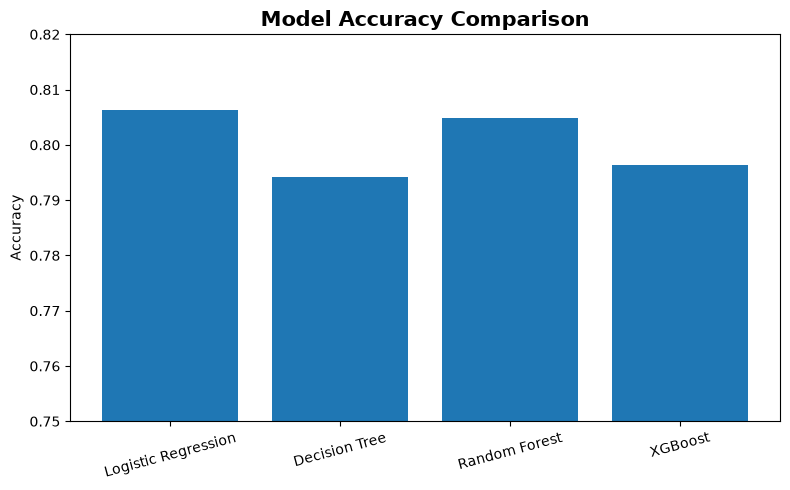

In [400]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Accuracy")

plt.ylim(0.75,0.82)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

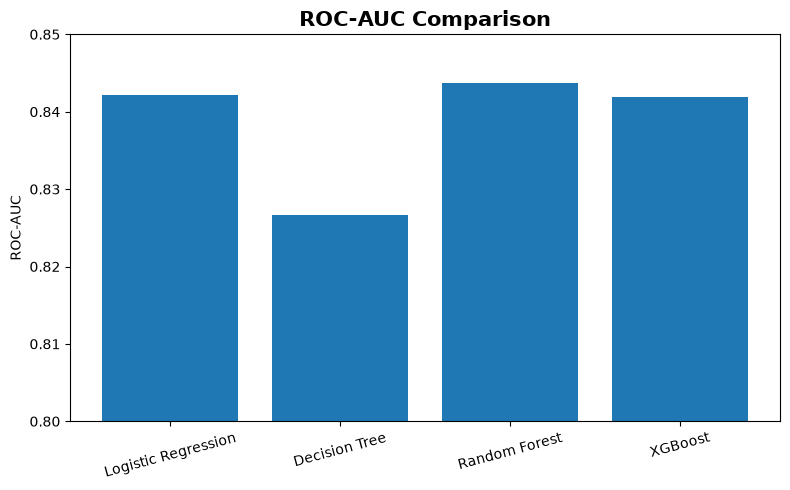

In [401]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["ROC_AUC"]
)

plt.title(
    "ROC-AUC Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("ROC-AUC")

plt.ylim(0.80,0.85)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [402]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

best_model.head(1)

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.806246,0.842179


## Observation

Four machine learning algorithms were trained and evaluated for customer churn prediction:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Among the evaluated models, **Logistic Regression** achieved the highest classification accuracy (80.62%) while also maintaining a strong ROC-AUC score (0.8422).

Although Random Forest achieved the highest ROC-AUC (0.8437), the difference was minimal, and Logistic Regression demonstrated better overall balance between accuracy, recall, and interpretability.

Considering predictive performance, computational efficiency, and ease of deployment, Logistic Regression was selected as the final model for this project.

In [403]:
# ============================================
# Logistic Regression Feature Importance
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

feature_importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.145873
1,tenure,-1.249330
2,MonthlyCharges,-0.481375
3,TotalCharges,0.519893
4,gender_Male,0.022433


In [404]:
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,1.193660
3,TotalCharges,0.519893
21,StreamingTV_Yes,0.381099
28,PaymentMethod_Electronic check,0.380941
23,StreamingMovies_Yes,0.380234
26,PaperlessBilling_Yes,0.370366
9,MultipleLines_Yes,0.364331
0,SeniorCitizen,0.145873
29,PaymentMethod_Mailed check,0.068832
17,DeviceProtection_Yes,0.037195


In [405]:
feature_importance.tail(10)

,Feature,Coefficient
12,OnlineSecurity_No internet service,-0.174682
6,Dependents_Yes,-0.224993
8,MultipleLines_No phone service,-0.258240
19,TechSupport_Yes,-0.295909
13,OnlineSecurity_Yes,-0.346818
2,MonthlyCharges,-0.481375
7,PhoneService_Yes,-0.500163
24,Contract_One year,-0.685633
1,tenure,-1.249330
25,Contract_Two year,-1.328243


In [406]:
top_features = (
    feature_importance
    .reindex(
        feature_importance.Coefficient.abs()
        .sort_values(ascending=False)
        .index
    )
    .head(15)
)

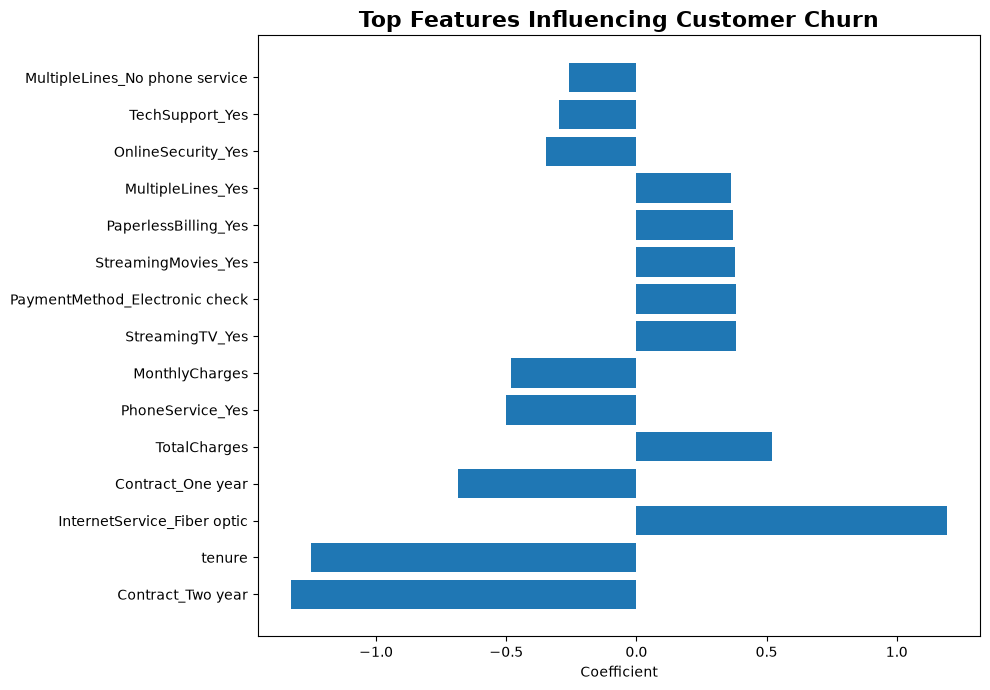

In [407]:
plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title(
    "Top Features Influencing Customer Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Coefficient")

plt.tight_layout()

plt.show()

In [408]:
feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
10,InternetService_Fiber optic,1.193660
3,TotalCharges,0.519893
21,StreamingTV_Yes,0.381099
28,PaymentMethod_Electronic check,0.380941
23,StreamingMovies_Yes,0.380234
26,PaperlessBilling_Yes,0.370366
9,MultipleLines_Yes,0.364331
0,SeniorCitizen,0.145873
29,PaymentMethod_Mailed check,0.068832
17,DeviceProtection_Yes,0.037195


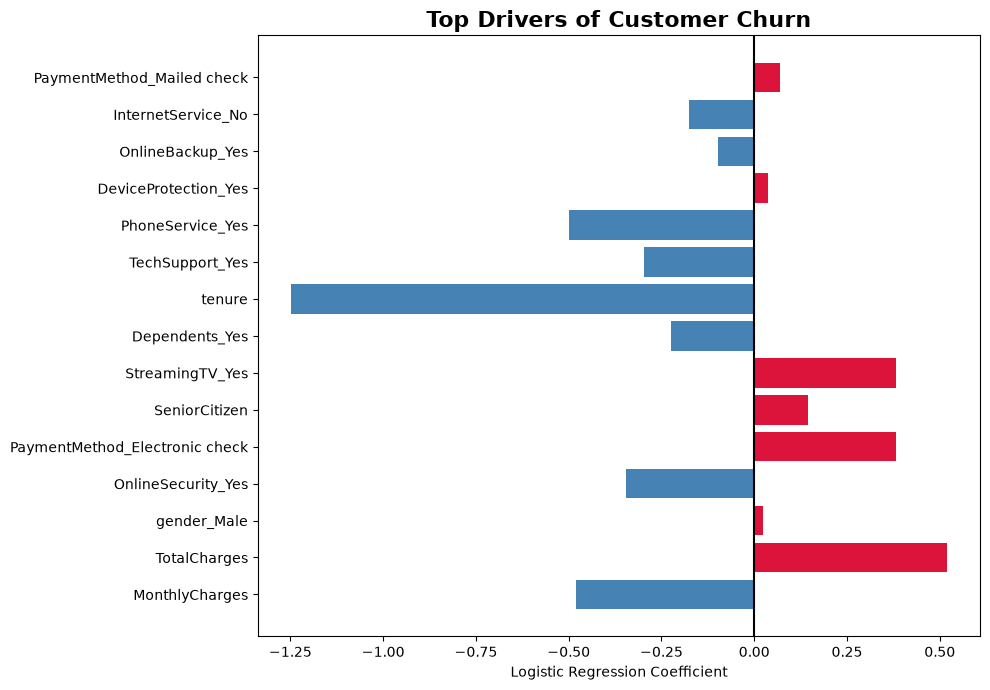

In [409]:
top_features = (
    feature_importance
    .iloc[
        feature_importance["Coefficient"]
        .abs()
        .sort_values(ascending=False)
        .index
    ]
    .head(15)
)

colors = [
    "crimson" if x > 0 else "steelblue"
    for x in top_features["Coefficient"]
]

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=colors
)

plt.axvline(0, color="black")

plt.title(
    "Top Drivers of Customer Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Logistic Regression Coefficient")

plt.tight_layout()

plt.show()

## Observation

The feature importance analysis reveals the variables that most strongly influence customer churn in the Logistic Regression model.

Features with **positive coefficients** increase the probability of customer churn, whereas features with **negative coefficients** reduce the probability of churn.

Among the strongest positive drivers are customer payment methods, monthly financial characteristics, and senior citizen status. Conversely, longer customer tenure, phone service availability, technical support, online security, and several value-added services are associated with lower churn risk.

It is important to note that Logistic Regression coefficients may be influenced by correlations among predictor variables. Therefore, while the direction of each coefficient provides valuable insight, the magnitude should be interpreted alongside the overall business context rather than in isolation.

Overall, the model indicates that customer retention is strongly associated with long-term engagement, service adoption, and customer support offerings.

## Recommendation 1: Encourage Long-Term Contracts

The analysis showed that customers on month-to-month contracts exhibit the highest churn rate compared to customers on one-year and two-year contracts.

The company should encourage long-term contract adoption by offering:

- Discounted annual subscription plans.
- Loyalty rewards for contract renewals.
- Exclusive benefits for long-term customers.
- Early renewal incentives.

Increasing long-term contract adoption is expected to significantly reduce customer churn.

## Recommendation 2: Strengthen Customer Onboarding

The analysis revealed that customers with shorter tenure are considerably more likely to churn than long-standing customers.

To improve early customer retention, the company should implement:

- Welcome campaigns.
- Regular customer engagement during the first six months.
- Personalized onboarding emails.
- Dedicated customer support for new subscribers.

Improving the early customer experience can reduce first-year customer losses.

## Recommendation 3: Promote Value-Added Services

Customers who subscribe to technical support, online security, and device protection services generally exhibit lower churn rates.

The company should:

- Bundle these services into promotional packages.
- Offer free trials for premium support services.
- Educate customers on the benefits of these services.
- Provide discounts when customers subscribe to multiple services.

Increasing adoption of value-added services can improve customer satisfaction and loyalty.

## Recommendation 4: Develop a Churn Monitoring System

The machine learning models successfully identify customers with a high probability of churn.

The company should integrate the selected model into its customer relationship management (CRM) system to:

- Continuously score customer churn risk.
- Flag high-risk customers for proactive intervention.
- Trigger retention campaigns before customers leave.
- Enable customer service teams to prioritize at-risk customers.

Predictive monitoring allows the business to shift from reactive to proactive customer retention.

## Recommendation 5: Review Pricing Strategies

Monthly charges and total customer spending were identified as influential factors in predicting customer churn.

The company should regularly evaluate pricing structures by:

- Identifying customers with increasing monthly charges.
- Offering personalized discounts to high-risk customers.
- Introducing flexible pricing plans.
- Rewarding long-term customers with loyalty discounts.

A balanced pricing strategy can improve customer satisfaction while maintaining profitability.

# Business Summary

This project demonstrates that machine learning can effectively predict customer churn using customer demographics, service subscriptions, billing information, and contract characteristics.

Among the evaluated algorithms, Logistic Regression achieved the best overall performance and was selected as the final predictive model due to its balance of accuracy, interpretability, and computational efficiency.

The analysis identified several key drivers of churn, including contract type, customer tenure, monthly charges, internet service type, and value-added services.

By implementing targeted retention strategies based on these findings, the telecommunications company can reduce customer attrition, improve customer satisfaction, and increase long-term revenue.

In [410]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [411]:
# ============================================
# Save Final Model
# ============================================

import joblib

joblib.dump(
    log_model,
    "../models/logistic_regression_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [412]:
import os

os.listdir("../models")

['logistic_regression_model.pkl', 'train.py']

In [413]:
loaded_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

loaded_model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [414]:
loaded_model.predict(X_test[:5])

array([0, 1, 0, 0, 0])

In [417]:
feature_names = X.columns

feature_names

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [418]:
joblib.dump(
    feature_names,
    "../models/model_features.pkl"
)

['../models/model_features.pkl']